# 1 实验标题

# Boosting 集成学习算法实验

本实验以真实公开的乳腺癌数据集为基础，使用 Python 和 Scikit-learn 实现 Boosting 集成学习算法。

实验主要研究 AdaBoost 和 Gradient Boosting 两种 Boosting 方法，通过数据探索、模型训练、参数设置、性能评价以及可视化分析，理解 Boosting 算法的基本思想和实际应用过程。

# 2 实验环境

## 主要 Python 库
- python版本————3.11.15
- NumPy：数值计算————1.26.4
- Pandas：数据处理————3.0.5
- Matplotlib：数据可视化————3.8.4
- Scikit-learn：机器学习算法————1.4.2

本实验使用 sklearn 官方实现的 Boosting 算法。

主要使用的算法：

- AdaBoostClassifier
- GradientBoostingClassifier
- DecisionTreeClassifier

In [1]:
# 查看当前实验环境中的 Python 和主要机器学习库版本

import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python版本：", sys.version)
print("NumPy版本：", np.__version__)
print("Pandas版本：", pd.__version__)
print("Matplotlib版本：", matplotlib.__version__)
print("Scikit-learn版本：", sklearn.__version__)

Python版本： 3.11.15 | packaged by conda-forge | (main, Aug 11 2026, 10:17:41) [MSC v.1944 64 bit (AMD64)]
NumPy版本： 1.26.4
Pandas版本： 3.0.5
Matplotlib版本： 3.8.4
Scikit-learn版本： 1.4.2


避免中文绘图报错

In [2]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

# 4 数据集介绍
## 4.1 数据来源
本实验使用 Scikit-learn 官方提供的 Breast Cancer Wisconsin Diagnostic Dataset
（乳腺癌威斯康星诊断数据集）。
该数据集来源于公开的 Wisconsin Breast Cancer Diagnostic 数据，
是机器学习分类实验中常用的真实医学数据集。
Scikit-learn 已经内置该数据集，因此不需要手动下载数据。
## 4.2 数据规模
数据集包含：
- 样本数量：569
- 特征数量：30
- 分类类别：2类
## 4.3 特征
数据中的特征主要描述乳腺肿瘤细胞的形态学特征，例如：
- 半径
- 纹理
- 周长
- 面积
- 平滑度
- 紧凑度
- 凹陷程度
- 凹点数量
- 对称性
- 分形维数
每类特征还包含不同的统计量，因此最终形成30维特征。
## 4.4 标签
分类标签共有两类：
- 0：恶性
- 1：良性
在实际建模过程中，需要注意 sklearn 数据集内部的类别编码，
因此本实验会将标签明确转换为：
- 0 → 恶性
- 1 → 良性

In [3]:
# 导入乳腺癌数据集

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("特征矩阵形状：", X.shape)
print("标签形状：", y.shape)

print("\n特征名称：")
print(data.feature_names)

print("\n原始类别名称：")
print(data.target_names)

特征矩阵形状： (569, 30)
标签形状： (569,)

特征名称：
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

原始类别名称：
['malignant' 'benign']


# 5 算法原理

## 5.1 Boosting 解决的问题

Boosting 是一种集成学习思想。

它的核心目标是：

> 将多个表现较弱的学习器逐步组合成一个性能较强的学习器。

例如，一个简单的决策树可能只能得到较普通的分类效果。

Boosting 不直接建立一棵非常复杂的决策树，而是：

1. 先训练一个简单模型；
2. 找出当前模型预测错误的样本；
3. 提高这些困难样本的重要程度；
4. 再训练新的弱学习器；
5. 重复上述过程；
6. 最终将所有弱学习器组合起来。

因此 Boosting 的特点是：

**“逐步纠错，逐步增强。”**

---

## 5.2 AdaBoost 核心思想

AdaBoost 的全称是：

Adaptive Boosting

其核心思想是：

> 每一轮训练都重点关注上一轮分类错误的样本。

假设训练集为：

$$
D=\{(x_1,y_1),(x_2,y_2),...,(x_n,y_n)\}
$$

最开始给每一个样本相同的权重：

$$
w_i=\frac{1}{n}
$$

训练第一个弱学习器：

$$
h_1(x)
$$

计算它的分类错误率：

$$
\epsilon_t=
\sum_{i=1}^{n}w_i I(y_i\neq h_t(x_i))
$$

其中：

- $w_i$：第 $i$ 个样本的权重
- $I(\cdot)$：指示函数
- $\epsilon_t$：第 $t$ 个弱学习器的错误率

然后计算该弱学习器在最终模型中的权重：

$$
\alpha_t=
\frac{1}{2}
\ln
\frac{1-\epsilon_t}{\epsilon_t}
$$

错误分类的样本会提高权重：

$$
w_i
\leftarrow
w_i
\exp(\alpha_t)
$$

正确分类的样本权重相对降低。

最后将所有弱学习器进行加权组合：

$$
H(x)=
sign
\left(
\sum_{t=1}^{T}
\alpha_t h_t(x)
\right)
$$

因此 AdaBoost 的本质可以概括为：

**不断寻找当前模型难以处理的样本，并让后续模型更加关注这些样本。**

---

## 5.3 Gradient Boosting 核心思想

Gradient Boosting 与 AdaBoost 的实现方式不同。

它的核心思想是：

> 每一轮学习前面模型预测结果的“残差”或损失函数的负梯度。

假设最终模型为：

$$
F(x)=
F_0(x)+
\eta h_1(x)+
\eta h_2(x)+
...+
\eta h_T(x)
$$

其中：

- $F_0(x)$：初始模型
- $h_t(x)$：第 $t$ 个弱学习器
- $\eta$：学习率
- $T$：弱学习器数量

每一轮都会针对当前模型的错误方向进行修正。

因此可以理解为：

> AdaBoost 更强调“提高错误样本权重”，而 Gradient Boosting 更强调“沿损失函数下降方向不断修正模型”。

---

## 5.4 Boosting 的基本流程

1. 初始化模型。
2. 训练第一个弱学习器。
3. 计算当前模型的预测错误。
4. 找到当前模型难以处理的部分。
5. 训练新的弱学习器进行修正。
6. 将新的学习器加入整体模型。
7. 重复上述过程。
8. 得到最终强学习器。

In [4]:
# 将数据转换为 Pandas DataFrame，便于进行数据探索

df = pd.DataFrame(X, columns=data.feature_names)

# 增加标签列
df["诊断结果"] = y

print("数据前5行：")
display(df.head())

print("\n数据形状：")
print(df.shape)

print("\n数据类型：")
print(df.dtypes.head())

数据前5行：


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,诊断结果
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



数据形状：
(569, 31)

数据类型：
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object


### 6.1 数据统计

In [5]:
# 输出数据的统计信息

pd.set_option("display.max_columns", None)

统计信息 = df.describe().T

统计信息 = 统计信息.rename(
    columns={
        "count": "样本数",
        "mean": "平均值",
        "std": "标准差",
        "min": "最小值",
        "25%": "25%分位数",
        "50%": "50%分位数",
        "75%": "75%分位数",
        "max": "最大值"
    }
)

display(统计信息)

,样本数,平均值,标准差,最小值,25%分位数,50%分位数,75%分位数,最大值
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 6.2 缺失值检查

在机器学习建模之前，需要检查数据中是否存在缺失值。
如果存在缺失值，需要进一步进行：
- 删除；
- 均值填充；
- 中位数填充；
- KNN填充等处理。

In [6]:
# 检查每个特征的缺失值数量

缺失值统计 = df.isnull().sum()

print("缺失值总数：", 缺失值统计.sum())

display(
    缺失值统计.to_frame("缺失值数量")
)

缺失值总数： 0


,缺失值数量
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### 6.3 类别分布

查看恶性和良性样本的数量。
类别分布对于分类问题非常重要，因为如果类别严重不平衡，
单纯使用准确率可能无法全面反映模型性能。

In [7]:
# 统计两个类别的样本数量

类别数量 = pd.Series(y).value_counts().sort_index()

类别名称 = ["恶性", "良性"]

类别统计表 = pd.DataFrame({
    "诊断结果": 类别名称,
    "样本数量": 类别数量.values
})

display(类别统计表)

,诊断结果,样本数量
0,恶性,212
1,良性,357


### 6.4 类别分布可视化

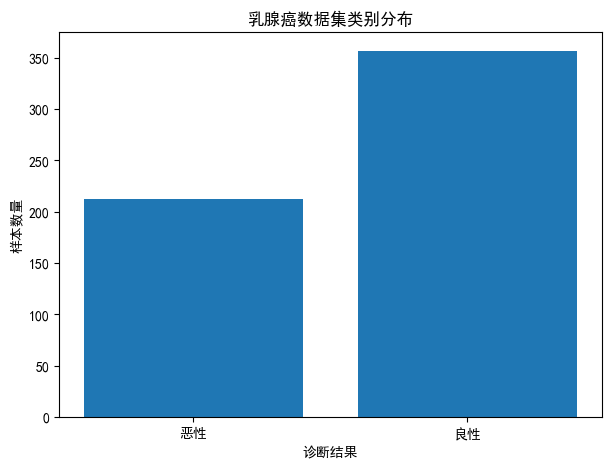

In [9]:
# 绘制类别分布柱状图
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["恶性", "良性"],
    类别数量.values
)

plt.title("乳腺癌数据集类别分布")
plt.xlabel("诊断结果")
plt.ylabel("样本数量")

plt.show()

# 7 模型建立

本实验建立两个 Boosting 模型：
## 模型一：AdaBoost
AdaBoost 使用多个弱学习器进行加权组合。
本实验选择深度为1的决策树作为弱学习器，即：
**决策树桩（Decision Stump）**
决策树桩只有一个分裂层级，本身属于非常简单的弱学习器。
AdaBoost 通过不断组合这些简单模型来获得较强的分类能力。

## 模型二：Gradient Boosting
Gradient Boosting 使用多棵浅层决策树逐步拟合前一轮模型的误差。
两个模型使用相同的训练集和测试集，
便于公平比较。

---

## 数据划分
将数据划分为：
- 训练集：80%
- 测试集：20%
使用 stratify 参数保证训练集和测试集中的类别比例基本一致。

In [10]:
# 划分训练集和测试集

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集样本数：", X_train.shape[0])
print("测试集样本数：", X_test.shape[0])

print("\n训练集类别分布：")
print(pd.Series(y_train).value_counts().sort_index())

print("\n测试集类别分布：")
print(pd.Series(y_test).value_counts().sort_index())

训练集样本数： 455
测试集样本数： 114

训练集类别分布：
0    170
1    285
Name: count, dtype: int64

测试集类别分布：
0    42
1    72
Name: count, dtype: int64


### 7.1 建立 AdaBoost 模型

这里设置：
- 基学习器：决策树桩
- 弱学习器数量：100
- 学习率：0.5
其中：
**n_estimators**
表示 Boosting 中弱学习器的数量。
数量越大，模型通常具有更强的表达能力，但训练时间也会增加，
同时过大的数量可能带来过拟合风险。
**learning_rate**
控制每个弱学习器对最终模型的贡献。
学习率较小通常需要更多的弱学习器。

In [15]:
# 建立 AdaBoost 分类模型

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# 创建决策树桩
弱学习器 = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

# 创建 AdaBoost 模型
ada_model = AdaBoostClassifier(
    estimator=弱学习器,
    n_estimators=100,
    learning_rate=0.5,
    algorithm="SAMME",
    random_state=42
)

print(ada_model)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=100, random_state=42)


### 7.2 建立 Gradient Boosting 模型
Gradient Boosting 同样采用多棵浅层决策树逐步建立最终模型。

关键参数：

- n_estimators：弱学习器数量
- learning_rate：学习率
- max_depth：每棵树的最大深度
- random_state：随机种子

通过限制树深度，可以避免单棵树过于复杂。

In [16]:
# 建立 Gradient Boosting 分类模型

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

print(gb_model)

GradientBoostingClassifier(learning_rate=0.05, max_depth=2, random_state=42)


# 8 模型训练

训练过程就是让模型从训练数据中学习：
$$
X_{train} \rightarrow y_{train}
$$
对于 AdaBoost：
1. 第一个决策树桩学习训练数据；
2. 计算分类错误；
3. 调整样本权重；
4. 第二个决策树桩重点关注错误样本；
5. 重复训练；
6. 最终得到多个弱学习器的加权组合。

对于 Gradient Boosting：

1. 建立初始模型；
2. 计算当前模型的损失；
3. 使用新的决策树拟合负梯度；
4. 将新的树加入模型；
5. 重复该过程。

下面正式进行训练。

In [17]:
# 训练 AdaBoost 模型

ada_model.fit(
    X_train,
    y_train
)

print("AdaBoost 模型训练完成")

AdaBoost 模型训练完成


In [18]:
# 训练 Gradient Boosting 模型

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting 模型训练完成")

Gradient Boosting 模型训练完成


### 8.1 模型预测

训练完成之后，需要使用测试集进行预测。
模型首先根据：
$$
X_{test}
$$
计算预测类别：
$$
\hat{y}
$$
然后将：
$$
\hat{y}
$$
与真实标签：
$$
y_{test}
$$
进行比较。

In [19]:
# 使用测试集进行预测

y_pred_ada = ada_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# 获取预测概率
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("AdaBoost预测完成")
print("Gradient Boosting预测完成")

AdaBoost预测完成
Gradient Boosting预测完成


# 9 实验结果

本实验使用以下指标评价模型：
## 准确率 Accuracy

$$
Accuracy=
\frac{TP+TN}
{TP+TN+FP+FN}
$$

表示所有样本中预测正确的比例。

---

## 精确率 Precision

$$
Precision=
\frac{TP}
{TP+FP}
$$

表示模型预测为正类的样本中，真正属于正类的比例。

---

## 召回率 Recall

$$
Recall=
\frac{TP}
{TP+FN}
$$

表示所有真实正类样本中，被模型正确识别出来的比例。

---

## F1值

$$
F1=
2
\times
\frac{Precision\times Recall}
{Precision+Recall}
$$

综合考虑精确率和召回率。

---

## ROC-AUC

ROC-AUC 用于衡量模型区分不同类别样本的整体能力。

AUC 越接近1，说明模型的分类能力通常越强。

In [20]:
# 计算两个模型的主要评价指标

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

结果 = []

for 模型名称, 真实值, 预测值, 预测概率 in [
    ("AdaBoost", y_test, y_pred_ada, y_prob_ada),
    ("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)
]:
    
    结果.append({
        "模型": 模型名称,
        "准确率": accuracy_score(真实值, 预测值),
        "精确率": precision_score(真实值, 预测值),
        "召回率": recall_score(真实值, 预测值),
        "F1值": f1_score(真实值, 预测值),
        "ROC-AUC": roc_auc_score(真实值, 预测概率)
    })

结果表 = pd.DataFrame(结果)

# 保留4位小数
结果表.iloc[:, 1:] = 结果表.iloc[:, 1:].round(4)

display(结果表)

,模型,准确率,精确率,召回率,F1值,ROC-AUC
0,AdaBoost,0.9561,0.9467,0.9861,0.9660,0.9835
1,Gradient Boosting,0.9386,0.9452,0.9583,0.9517,0.9911


### 9.1 输出模型参数

为了保证实验具有可重复性，需要记录模型的重要参数。

In [21]:
# 输出 AdaBoost 的关键参数

print("========== AdaBoost 参数 ==========")

print("弱学习器数量：", ada_model.n_estimators)
print("学习率：", ada_model.learning_rate)
print("弱学习器最大深度：", ada_model.estimator.max_depth)

print("\n========== Gradient Boosting 参数 ==========")

print("弱学习器数量：", gb_model.n_estimators)
print("学习率：", gb_model.learning_rate)
print("弱学习器最大深度：", gb_model.max_depth)

========== AdaBoost 参数 ==========
弱学习器数量： 100
学习率： 0.5
弱学习器最大深度： 1

========== Gradient Boosting 参数 ==========
弱学习器数量： 100
学习率： 0.05
弱学习器最大深度： 2


### 9.2 混淆矩阵

混淆矩阵可以更加具体地观察：

- 真正例 TP
- 真负例 TN
- 假正例 FP
- 假负例 FN

对于医学分类任务而言，除了整体准确率之外，
还需要关注模型是否存在大量漏诊情况。

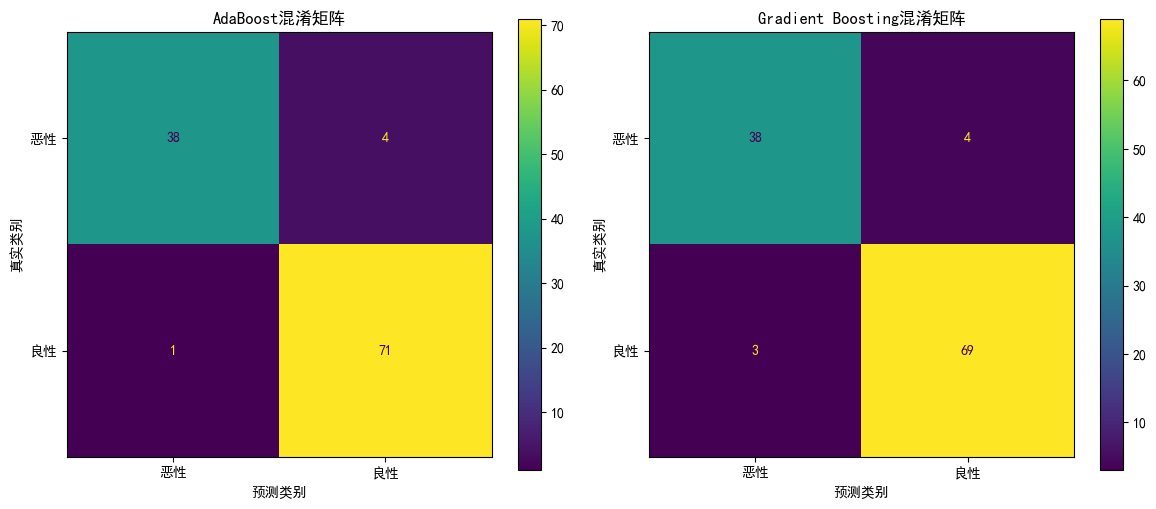

In [22]:
# 绘制 AdaBoost 和 Gradient Boosting 的混淆矩阵

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ada,
    display_labels=["恶性", "良性"],
    ax=axes[0]
)

axes[0].set_title("AdaBoost混淆矩阵")
axes[0].set_xlabel("预测类别")
axes[0].set_ylabel("真实类别")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=["恶性", "良性"],
    ax=axes[1]
)

axes[1].set_title("Gradient Boosting混淆矩阵")
axes[1].set_xlabel("预测类别")
axes[1].set_ylabel("真实类别")

plt.tight_layout()
plt.show()

# 10 可视化分析

## 10.1 ROC曲线

ROC曲线以：

- 横轴：假正例率
- 纵轴：真正例率

来描述分类模型在不同分类阈值下的表现。

通过比较两个模型的 ROC 曲线，
可以观察 AdaBoost 和 Gradient Boosting 的分类能力。

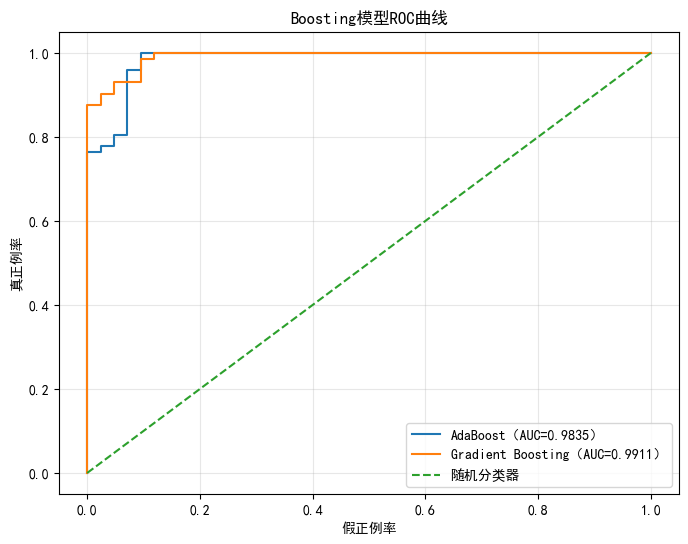

In [23]:
# 绘制两个模型的 ROC 曲线

from sklearn.metrics import roc_curve

fpr_ada, tpr_ada, _ = roc_curve(
    y_test,
    y_prob_ada
)

fpr_gb, tpr_gb, _ = roc_curve(
    y_test,
    y_prob_gb
)

auc_ada = roc_auc_score(y_test, y_prob_ada)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_ada,
    tpr_ada,
    label=f"AdaBoost（AUC={auc_ada:.4f}）"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting（AUC={auc_gb:.4f}）"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="随机分类器"
)

plt.title("Boosting模型ROC曲线")
plt.xlabel("假正例率")
plt.ylabel("真正例率")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 10.2 不同弱学习器数量对模型性能的影响

Boosting 的一个重要参数是：

$$
T=n\_estimators
$$

它表示弱学习器的数量。

一般而言：

- 弱学习器太少 → 模型可能欠拟合；
- 弱学习器增加 → 模型通常逐渐提高；
- 过多的弱学习器 → 训练时间增加，并可能出现过拟合。

下面实验不同弱学习器数量对 AdaBoost 测试集准确率的影响。

In [25]:
# 分析弱学习器数量对 AdaBoost 准确率的影响

estimator_numbers = [10, 20, 50, 100, 150, 200]

准确率列表 = []

for n in estimator_numbers:
    
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=n,
        learning_rate=0.5,
        algorithm="SAMME",
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    
    准确率列表.append(acc)

参数实验结果 = pd.DataFrame({
    "弱学习器数量": estimator_numbers,
    "测试集准确率": np.round(准确率列表, 4)
})

display(参数实验结果)

,弱学习器数量,测试集准确率
0,10,0.9649
1,20,0.9649
2,50,0.9561
3,100,0.9561
4,150,0.9649
5,200,0.9561


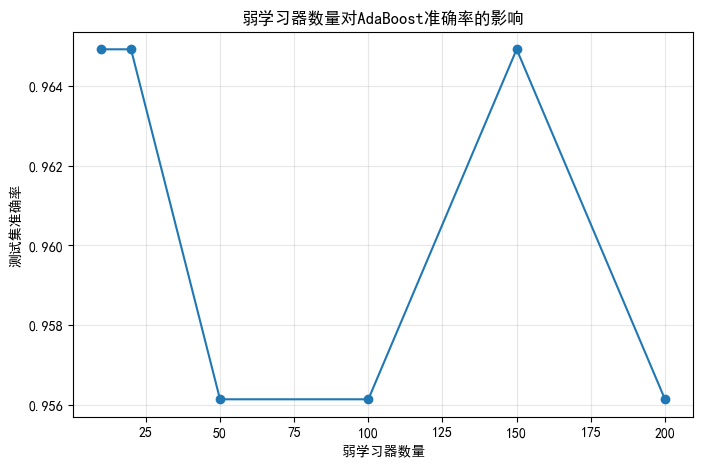

In [26]:
# 绘制弱学习器数量与测试集准确率之间的关系

plt.figure(figsize=(8, 5))

plt.plot(
    estimator_numbers,
    准确率列表,
    marker="o"
)

plt.title("弱学习器数量对AdaBoost准确率的影响")
plt.xlabel("弱学习器数量")
plt.ylabel("测试集准确率")

plt.grid(alpha=0.3)

plt.show()

## 10.3 AdaBoost训练过程分析

AdaBoost 的训练过程中，每增加一个弱学习器，
整体模型都会进一步修正之前模型的错误。

因此可以通过 staged_predict 方法观察：
随着弱学习器数量不断增加，测试集准确率如何变化。

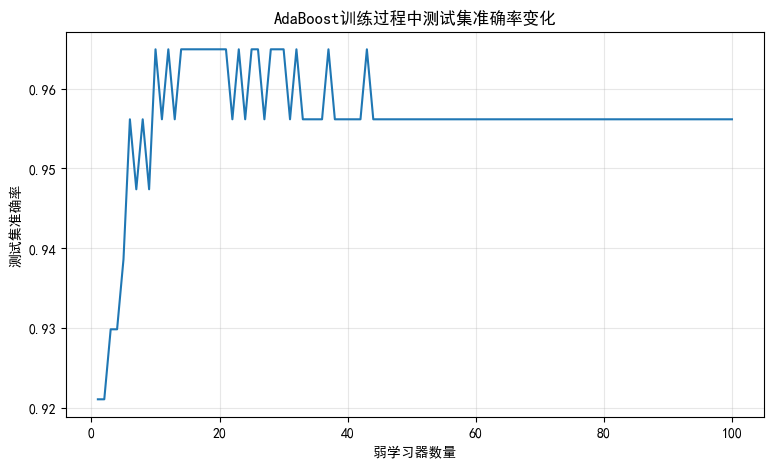

In [27]:
# 获取 AdaBoost 每一轮迭代后的测试集预测结果

stage_accuracy = []

for pred in ada_model.staged_predict(X_test):
    
    acc = accuracy_score(
        y_test,
        pred
    )
    
    stage_accuracy.append(acc)

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(stage_accuracy) + 1),
    stage_accuracy
)

plt.title("AdaBoost训练过程中测试集准确率变化")
plt.xlabel("弱学习器数量")
plt.ylabel("测试集准确率")

plt.grid(alpha=0.3)

plt.show()

# 11 模型评价

## 11.1 AdaBoost模型分析

AdaBoost 的主要特点是：

1. 使用多个弱学习器组合成强学习器。
2. 每轮训练都会重点关注之前预测错误的样本。
3. 决策树桩等简单模型也可以通过集成获得较好的分类能力。
4. 参数相对较少，实现简单。

本实验使用最大深度为1的决策树作为弱学习器，
因此单棵树本身的分类能力非常有限。

但是经过多轮 Boosting 后，
多个弱学习器共同形成了较强的分类器。

---

## 11.2 Gradient Boosting模型分析

Gradient Boosting 与 AdaBoost 的核心机制有所不同。

它不是简单地提高错误样本的权重，
而是根据损失函数的梯度方向，
不断建立新的弱学习器来修正已有模型。

因此 Gradient Boosting 通常具有较强的非线性建模能力。

---
## 11.4 Boosting的优点

1. 可以将多个弱学习器组合成强学习器。
2. 能够处理复杂的非线性关系。
3. 通常具有较高的预测精度。
4. 不需要建立一个非常复杂的单一模型。
5. sklearn 提供了成熟的实现。
---
## 11.5 Boosting的缺点
1. Boosting 模型训练过程具有一定的顺序性。
2. 训练多个弱学习器需要一定计算成本。
3. 参数较多时需要进行调参。
4. 对异常数据和噪声数据可能比较敏感。
5. 弱学习器数量过多时可能出现过拟合。

![Boosting算法流程图](Boosting算法实验流程图.png)